In [1]:
MODEL_CLS = "delf"
DATASET = "amusic"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
    FILTER = "tfidf"
    MAX_LEN = 128
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
    FILTER = "default"
    MAX_LEN = None
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
    FILTER = "default"
    MAX_LEN = None
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
    FILTER = "tfidf"
    MAX_LEN = 400
else:
    raise ValueError()

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\11_RS-DELF


In [5]:
import sys
sys.path.append("src")

# Config

In [6]:
import pandas as pd
from components import histories
from pointwise import config, datamodule, trainer, evaluator, utils
import delf

In [7]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [8]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 5541
number of item: 3568
total interaction: 64706
interaction density: 0.3273 %
max interaction of user: 578
max interaction of item: 272
top 10.0 % interaction of user: 20.0
top 10.0 % interaction of item: 40.0
mean interaction of user: 11
mean interaction of item: 18


In [11]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, trn = datamodule.build(**kwargs)

In [12]:
kwargs = dict(
    df=trn,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    filter=FILTER,
    max_len=MAX_LEN,
)

histories_cls = dict(
    user=histories.Histories(
        anchor="user", 
        **kwargs,
    ),
    item=histories.Histories(
        anchor="item", 
        **kwargs,
    ),
)

# Modeling

In [13]:
kwargs = dict(
    histories=histories_cls,
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model.params,
)

model = delf.delf.DualEmbeddingDeepLatentFactorModel(**kwargs)

# Train

In [14]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [15]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 16
BEST SCORE: 0.4597


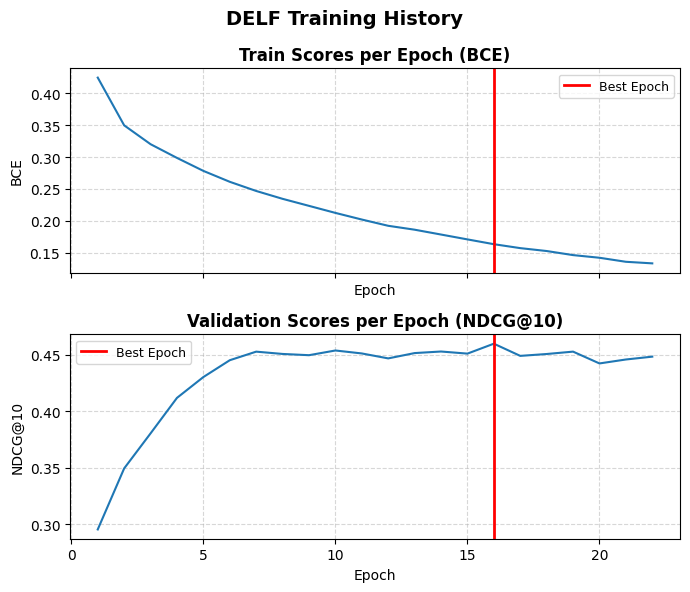

In [16]:
kwargs = dict(
    records=records,
    suptitle="DELF Training History",
    trn="BCE",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [17]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [18]:
result, metrics_sheet = msr(dataloaders["tst"])

TST: 100%|██████████| 760/760 [00:07<00:00, 97.07it/s] 


In [19]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.583830,0.126656,0.534389,0.350594,0.405987
1,10,0.726223,0.082187,0.676121,0.371821,0.453479
2,15,0.797690,0.061986,0.751716,0.378952,0.474772
3,20,0.841545,0.049955,0.799965,0.382268,0.486962
4,25,0.876376,0.042180,0.838164,0.384343,0.495927
5,50,0.954882,0.023999,0.929495,0.387888,0.515301


# Save

In [20]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)